<a href="https://colab.research.google.com/github/NSP2023/ML-Learning-and-tasks/blob/Lab2/Lab2_220041120.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab2_220041120_1B

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder ,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler ,StandardScaler
%matplotlib inline
sns.set_theme(style="whitegrid")
print("All libraries are loaded successfully")


All libraries are loaded successfully


In [77]:
file_path="/content/Titanic-Dataset.csv"
df=pd.read_csv(file_path)


#Task 1: Data Loading and Inspection



In [78]:
df=pd.read_csv(file_path)

print("Loading  the Titanic CSV and displaying the first 10 rows :")
print(df.head(10))

print("Printing column names :")
print(df.columns.tolist())
print()

print("Printing Shape : ")
print(df.shape)
print()

print("Printing data types :")
print(df.dtypes)
numerical_cols=df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns
print()



print("Numerical vs categorical")
print("Numerical: ",numerical_cols)
print("Categorial: ",categorical_cols)
print()



print("People more than average ")
avg_fare=df['Fare'].mean()
rich_people=df[df['Fare']>avg_fare]['Name']
print(rich_people)
print()


print("Missing value")
missing_percent=(df.isnull().sum()/len(df))*100
missing_percent=missing_percent.sort_values(ascending=False)
print(missing_percent)
print()


Loading  the Titanic CSV and displaying the first 10 rows :
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6   

#Task 2: Handling Missing Values


Droping the Cabin column
Columns Remaining : 11

Filling missing age with median
Median Age: 28.0

Missing in Age after imputation: 0

Before filling histogram: 

After filling 


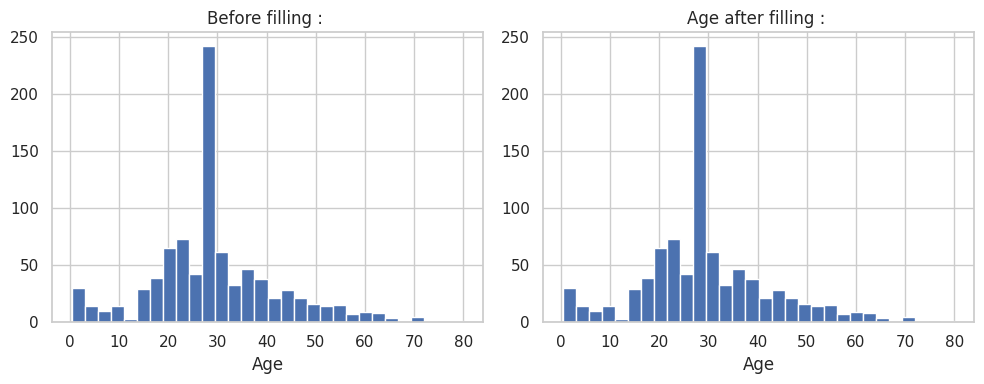


Mode of Embarked: S

Missing values after imputation: PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Total missing :  0


In [79]:
df = pd.read_csv(file_path)

print("Droping the Cabin column")
df=df.drop(columns=['Cabin'])
print(f"Columns Remaining : {df.shape[1]}")
print()


#saving the original age
age_before=df['Age'].copy()



print('Filling missing age with median')
age_median = age_before.median()
print(f"Median Age: {age_median}")
print()

df['Age'] = age_before.fillna(age_median)
print(f"Missing in Age after imputation: {df['Age'].isnull().sum()}")
print()

print("Before filling histogram: ")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['Age'].hist(bins=30)
plt.title("Before filling : ")
plt.xlabel("Age")
print()

print("After filling ")
plt.subplot(1,2,2)
df['Age'].fillna(age_median).hist(bins=30)
plt.title("Age after filling : ")
plt.xlabel("Age")
plt.tight_layout()
plt.show()
print()


embarked_mode=df['Embarked'].mode()[0]
print(f"Mode of Embarked: {embarked_mode}")
print()

df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print(f"Missing values after imputation: {df.isnull().sum()}")
print()

print("Total missing : ", df.isnull().sum().sum())

#Task 3: Encoding and Scaling

In [80]:
le=LabelEncoder()
df['Sex_encoded']=le.fit_transform(df['Sex'])

print("Encoding to the Sex column: ")
print("Classes: ",le.classes_)
print(df[['Sex','Sex_encoded']].head())
print()

#if embarked exist
if 'Embarked' in df.columns:
    print("One-Hot Encoding")
    embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)
    print(embarked_dummies.head())

    df=pd.concat([df, embarked_dummies],axis=1)
    df=df.drop(columns=['Embarked'])
    print()
else:
    print("Warning: 'Embarked' column not found. Skipping One-Hot Encoding.")
    print()

minmax=MinMaxScaler()

minmax = MinMaxScaler()
df[['Age_minmax', 'Fare_minmax']] = minmax.fit_transform(df[['Age', 'Fare']])

print("Scaled values preview:")
print(df[['Age','Age_minmax','Fare','Fare_minmax']].head())
print()

#verifying range
print("Age_minmax : Min:", df['Age_minmax'].min(),
      "Max:", df['Age_minmax'].max())

print("Fare_minmax  : Min:", df['Fare_minmax'].min(),
      "Max:", df['Fare_minmax'].max())


Encoding to the Sex column: 
Classes:  ['female' 'male']
      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1

One-Hot Encoding
   Embarked_Q  Embarked_S
0       False        True
1       False       False
2       False        True
3       False        True
4       False        True

Scaled values preview:
    Age  Age_minmax     Fare  Fare_minmax
0  22.0    0.271174   7.2500     0.014151
1  38.0    0.472229  71.2833     0.139136
2  26.0    0.321438   7.9250     0.015469
3  35.0    0.434531  53.1000     0.103644
4  35.0    0.434531   8.0500     0.015713

Age_minmax : Min: 0.0 Max: 1.0
Fare_minmax  : Min: 0.0 Max: 1.0


#Task 4: Exploratory Data Analysis

### (a) Histogram

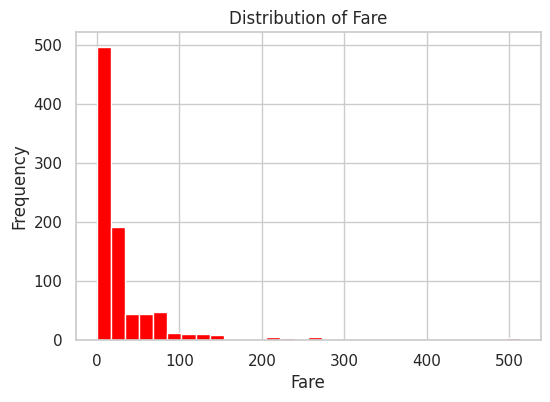

In [81]:
plt.figure(figsize=(6,4))
plt.hist(df['Fare'],bins=30, color='red', edgecolor='white')
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


###(b) Bar chart:


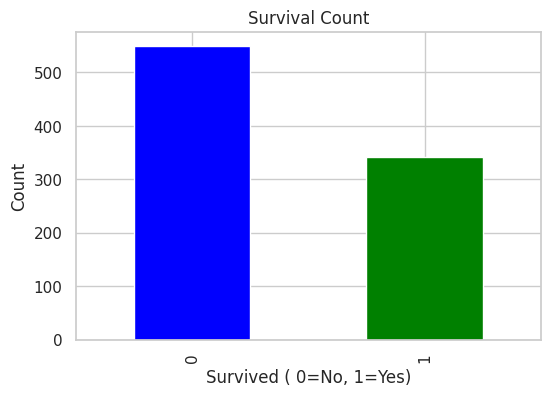

In [82]:
plt.figure(figsize=(6,4))
df['Survived'].value_counts().plot(
    kind='bar',
    color=['blue','green'],
    edgecolor='white'

)


plt.title("Survival Count")
plt.xlabel("Survived ( 0=No, 1=Yes)")
plt.ylabel("Count")

plt.show()

### (c) Box plot:

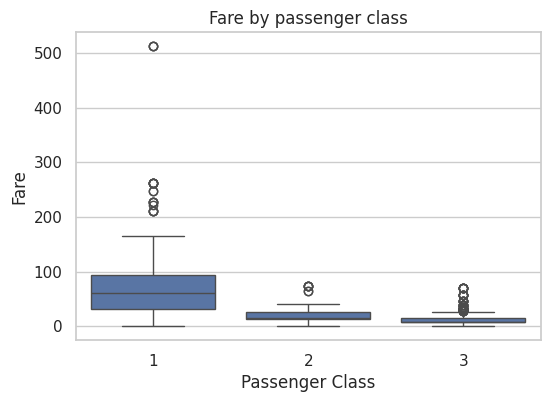

In [83]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title("Fare by passenger class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()


###(d) Correlation heatmap:

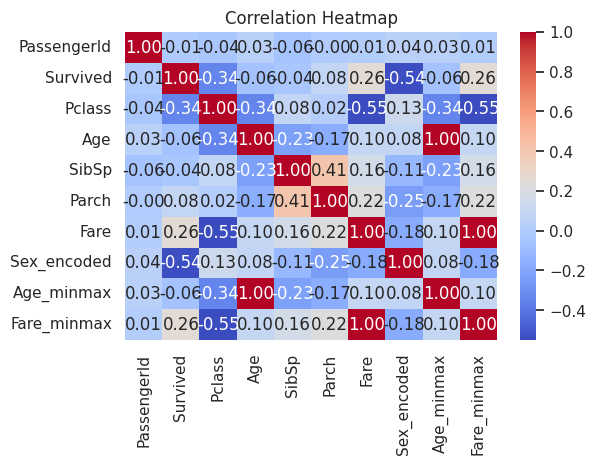

Top 3 features with the survival
Survived       1.000000
Sex_encoded    0.543351
Pclass         0.338481
Fare           0.257307
Fare_minmax    0.257307
Parch          0.081629
Age            0.064910
Age_minmax     0.064910
SibSp          0.035322
PassengerId    0.005007
Name: Survived, dtype: float64


In [84]:
numeric_df=df.select_dtypes(include=[np.number])
corr_matrix=numeric_df.corr()
plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


print("Top 3 features with the survival")
corr_with_target=corr_matrix['Survived'].abs().sort_values(ascending=False)
print(corr_with_target)


###(e)KDE plot:

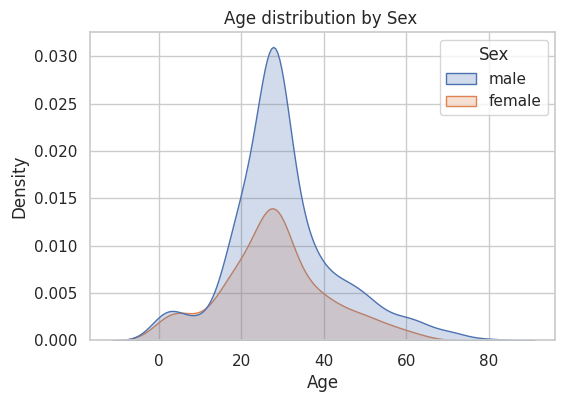

In [85]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='Age',hue='Sex',fill=True)

plt.title("Age distribution by Sex ")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

#Task 5: Open-Ended Investigation

/tmp/ipykernel_12259/4189643501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex',y='Survived', palette=['orange','green'])


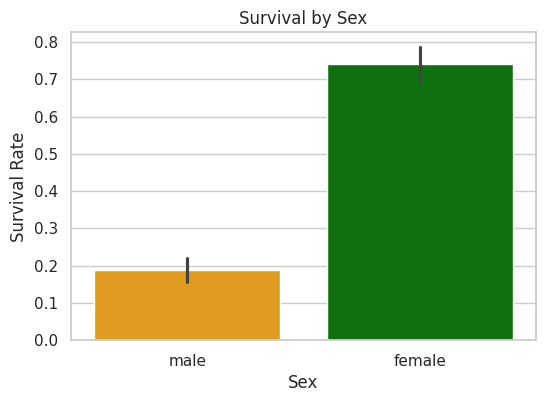

/tmp/ipykernel_12259/4189643501.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Child', y='Survived', palette=['pink','teal'])


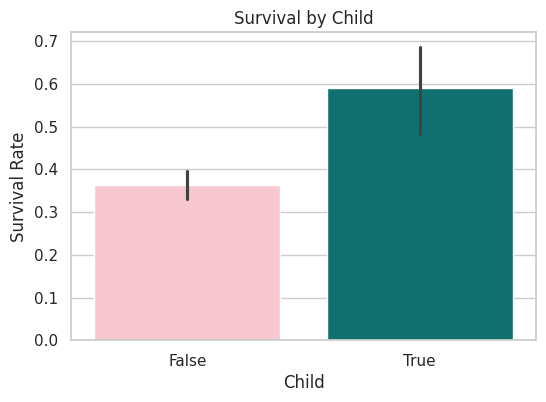

In [86]:
df['Age']=df['Age'].fillna(df['Age'].median())   #filling up any missing data

df['Child']=df['Age']< 16   # definig child


#visual 1

plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Sex',y='Survived', palette=['orange','green'])

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

print()



#visual 2
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Child', y='Survived', palette=['pink','teal'])
plt.title("Survival by Child")
plt.xlabel("Child")
plt.ylabel("Survival Rate")
plt.show()
